# FIFA 21 Data Cleaning & Exploratory Data Analysis

This project focuses on cleaning and transforming a messy scraped FIFA 21 dataset into an analysis-ready format using Python and Jupyter Notebook.

The dataset required extensive preprocessing due to inconsistent formatting in financial values, player attributes, and contract details.

In [1]:
import pandas as pd
import numpy as np



In [2]:
df = pd.read_csv("fifa21_raw_data.csv")

C:\Users\Grace Sikeina Mahama\AppData\Local\Temp\ipykernel_10044\4215608658.py:1: DtypeWarning: Columns (76) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("fifa21_raw_data.csv")


## 1. Data Overview

The dataset was scraped from sofifa.com and contains player information including height, weight, value, wage, contract details, and performance ratings.

Due to web scraping inconsistencies, several columns required cleaning and type conversion.

In [3]:
df.head()

,photoUrl,LongName,playerUrl,Nationality,Positions,Name,Age,↓OVA,POT,Team & Contract,...,A/W,D/W,IR,PAC,SHO,PAS,DRI,DEF,PHY,Hits
0,https://cdn.sofifa.com/players/158/023/21_60.png,Lionel Messi,http://sofifa.com/player/158023/lionel-messi/2...,Argentina,RW ST CF,L. Messi,33,93,93,\n\n\n\nFC Barcelona\n2004 ~ 2021\n\n,...,Medium,Low,5 ★,85,92,91,95,38,65,\n372
1,https://cdn.sofifa.com/players/020/801/21_60.png,C. Ronaldo dos Santos Aveiro,http://sofifa.com/player/20801/c-ronaldo-dos-s...,Portugal,ST LW,Cristiano Ronaldo,35,92,92,\n\n\n\nJuventus\n2018 ~ 2022\n\n,...,High,Low,5 ★,89,93,81,89,35,77,\n344
2,https://cdn.sofifa.com/players/200/389/21_60.png,Jan Oblak,http://sofifa.com/player/200389/jan-oblak/210005/,Slovenia,GK,J. Oblak,27,91,93,\n\n\n\nAtlético Madrid\n2014 ~ 2023\n\n,...,Medium,Medium,3 ★,87,92,78,90,52,90,\n86
3,https://cdn.sofifa.com/players/192/985/21_60.png,Kevin De Bruyne,http://sofifa.com/player/192985/kevin-de-bruyn...,Belgium,CAM CM,K. De Bruyne,29,91,91,\n\n\n\nManchester City\n2015 ~ 2023\n\n,...,High,High,4 ★,76,86,93,88,64,78,\n163
4,https://cdn.sofifa.com/players/190/871/21_60.png,Neymar da Silva Santos Jr.,http://sofifa.com/player/190871/neymar-da-silv...,Brazil,LW CAM,Neymar Jr,28,91,91,\n\n\n\nParis Saint-Germain\n2017 ~ 2022\n\n,...,High,Medium,5 ★,91,85,86,94,36,59,\n273


In [4]:
df.tail()

,photoUrl,LongName,playerUrl,Nationality,Positions,Name,Age,↓OVA,POT,Team & Contract,...,A/W,D/W,IR,PAC,SHO,PAS,DRI,DEF,PHY,Hits
18974,https://cdn.sofifa.com/players/257/710/21_60.png,Mengxuan Zhang,http://sofifa.com/player/257710/mengxuan-zhang...,China PR,CB,Zhang Mengxuan,21,47,52,\n\n\n\nChongqing Dangdai Lifan FC SWM Team\n2...,...,Low,Low,1 ★,58,23,26,27,50,48,2
18975,https://cdn.sofifa.com/players/258/736/21_60.png,Vani Da Silva,http://sofifa.com/player/258736/vani-da-silva/...,England,ST,V. Da Silva,17,47,67,\n\n\n\nOldham Athletic\n2020 ~ 2021\n\n,...,Medium,Medium,1 ★,70,46,40,53,16,40,3
18976,https://cdn.sofifa.com/players/247/223/21_60.png,Ao Xia,http://sofifa.com/player/247223/ao-xia/210005/,China PR,CB,Xia Ao,21,47,55,\n\n\n\nWuhan Zall\n2018 ~ 2022\n\n,...,Medium,Medium,1 ★,64,28,26,38,48,51,3
18977,https://cdn.sofifa.com/players/258/760/21_60.png,Ben Hough,http://sofifa.com/player/258760/ben-hough/210005/,England,CM,B. Hough,17,47,67,\n\n\n\nOldham Athletic\n2020 ~ 2021\n\n,...,Medium,Medium,1 ★,64,40,48,49,35,45,5
18978,https://cdn.sofifa.com/players/255/958/21_60.png,Mateo Flores,http://sofifa.com/player/255958/mateo-flores/2...,Bolivia,CDM,M. Flores,19,47,63,\n\n\n\nClub Bolívar\n2020 ~ 2024\n\n,...,Medium,Medium,1 ★,57,32,43,48,44,49,2


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18979 entries, 0 to 18978
Data columns (total 77 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   photoUrl          18979 non-null  object
 1   LongName          18979 non-null  object
 2   playerUrl         18979 non-null  object
 3   Nationality       18979 non-null  object
 4   Positions         18979 non-null  object
 5   Name              18979 non-null  object
 6   Age               18979 non-null  int64 
 7   ↓OVA              18979 non-null  int64 
 8   POT               18979 non-null  int64 
 9   Team & Contract   18979 non-null  object
 10  ID                18979 non-null  int64 
 11  Height            18979 non-null  object
 12  Weight            18979 non-null  object
 13  foot              18979 non-null  object
 14  BOV               18979 non-null  int64 
 15  BP                18979 non-null  object
 16  Growth            18979 non-null  int64 
 17  Joined      

In [6]:
df.describe()

,Age,↓OVA,POT,ID,BOV,Growth,Attacking,Crossing,Finishing,Heading Accuracy,...,GK Positioning,GK Reflexes,Total Stats,Base Stats,PAC,SHO,PAS,DRI,DEF,PHY
count,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,...,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000,18979.000000
mean,25.194583,65.718636,71.136098,226404.790242,66.751620,5.417461,248.938616,49.688551,45.842932,51.941883,...,16.217609,16.519205,1595.293851,355.703040,67.454239,53.457716,57.681069,62.875494,49.865904,64.368618
std,4.710753,6.968999,6.114176,27141.673349,6.747017,5.663954,74.299764,18.131334,19.566978,17.293626,...,17.002134,17.854185,269.883542,40.762282,10.678058,13.827229,10.081914,9.927875,16.442730,9.601665
min,16.000000,47.000000,47.000000,41.000000,48.000000,0.000000,42.000000,6.000000,3.000000,5.000000,...,2.000000,2.000000,747.000000,232.000000,25.000000,16.000000,25.000000,25.000000,12.000000,28.000000
25%,21.000000,61.000000,67.000000,210135.000000,62.000000,0.000000,222.000000,38.000000,30.000000,44.000000,...,8.000000,8.000000,1452.000000,327.000000,61.000000,44.000000,51.000000,57.000000,35.000000,58.000000
50%,25.000000,66.000000,71.000000,232424.000000,67.000000,4.000000,263.000000,54.000000,49.000000,55.000000,...,11.000000,11.000000,1627.000000,356.000000,68.000000,56.000000,58.000000,64.000000,53.000000,65.000000
75%,29.000000,70.000000,75.000000,246925.500000,71.000000,9.000000,297.000000,63.000000,62.000000,64.000000,...,14.000000,14.000000,1781.000000,384.000000,75.000000,64.000000,64.000000,69.000000,63.000000,71.000000
max,53.000000,93.000000,95.000000,259216.000000,93.000000,26.000000,437.000000,94.000000,95.000000,93.000000,...,91.000000,90.000000,2316.000000,498.000000,96.000000,93.000000,93.000000,95.000000,91.000000,91.000000


In [7]:
df.isnull().sum()

photoUrl       0
LongName       0
playerUrl      0
Nationality    0
Positions      0
              ..
PAS            0
DRI            0
DEF            0
PHY            0
Hits           0
Length: 77, dtype: int64

## 2. Data Cleaning

The following transformations were performed:

- Converted height from feet/inches to centimeters
- Converted weight to numeric format
- Converted Value, Wage, and Release Clause into numeric euro values
- Removed star characters from rating columns
- Removed newline characters

##### Clean Height and Weight #

In [8]:
df["Height"].unique()[:20]

array(['5\'7"', '6\'2"', '5\'11"', '5\'9"', '6\'0"', '5\'10"', '6\'3"',
       '6\'4"', '6\'1"', '6\'6"', '5\'8"', '5\'6"', '6\'5"', '5\'5"',
       '5\'4"', '6\'7"', '5\'2"', '5\'3"', '6\'8"', '5\'1"'], dtype=object)

In [9]:
import numpy as np

def convert_height(height):
    try:
        height = str(height).strip()
        
        if "'" in height:
            parts = height.split("'")
            feet = int(parts[0])
            inches = int(parts[1].replace('"', ''))
            return round((feet * 30.48) + (inches * 2.54), 2)
        
        return np.nan
    
    except:
        return np.nan

df["Height_cm"] = df["Height"].apply(convert_height)

In [10]:
import numpy as np

def convert_height(height):
    try:
        height = str(height).strip()
        
        if "'" in height:
            parts = height.split("'")
            feet = int(parts[0])
            inches = int(parts[1].replace('"', ''))
            return round((feet * 30.48) + (inches * 2.54), 2)
        
        return np.nan
    
    except:
        return np.nan

df["Height_cm"] = df["Height"].apply(convert_height)

In [11]:
df[["Height", "Height_cm"]].head(10)

,Height,Height_cm
0,"5'7""",170.18
1,"6'2""",187.96
2,"6'2""",187.96
3,"5'11""",180.34
4,"5'9""",175.26
5,"6'0""",182.88
6,"5'10""",177.80
7,"6'3""",190.50
8,"5'9""",175.26
9,"5'9""",175.26


In [12]:
df["Height_cm"].describe() #155 cm → shorter players

#206 cm → tall goalkeepers

count    18979.000000
mean       181.224095
std          6.819052
min        154.940000
25%        175.260000
50%        180.340000
75%        185.420000
max        205.740000
Name: Height_cm, dtype: float64

#### Convert Weight to Kilograms #

In [13]:
df["Weight_kg"] = (
    df["Weight"]
    .str.replace("lbs", "", regex=False)
    .astype(float) * 0.453592
)

df[["Weight", "Weight_kg"]].head()

,Weight,Weight_kg
0,159lbs,72.121128
1,183lbs,83.007336
2,192lbs,87.089664
3,154lbs,69.853168
4,150lbs,68.038800


In [14]:
df["Weight_kg"].describe() #to validate the change
#49.8 kg → lightweight winger or young player ✅

#110 kg → big defender/goalkeeper

count    18979.000000
mean        75.018606
std          7.070560
min         49.895120
25%         69.853168
50%         74.842680
75%         79.832192
max        110.222856
Name: Weight_kg, dtype: float64

#### Value, Wage & Release Clause #

In [15]:
df[["Value", "Wage", "Release Clause"]].head(10)

,Value,Wage,Release Clause
0,€67.5M,€560K,€138.4M
1,€46M,€220K,€75.9M
2,€75M,€125K,€159.4M
3,€87M,€370K,€161M
4,€90M,€270K,€166.5M
5,€80M,€240K,€132M
6,€105.5M,€160K,€203.1M
7,€62.5M,€160K,€120.3M
8,€78M,€250K,€144.3M
9,€78M,€250K,€144.3M


In [16]:
import numpy as np

def convert_currency(value):
    try:
        value = str(value).strip()
        value = value.replace('€', '')
        
        if 'M' in value:
            return float(value.replace('M', '')) * 1_000_000
        
        elif 'K' in value:
            return float(value.replace('K', '')) * 1_000
        
        else:
            return float(value)
    
    except:
        return np.nan

In [17]:
df["Value_num"] = df["Value"].apply(convert_currency)
df["Wage_num"] = df["Wage"].apply(convert_currency)
df["ReleaseClause_num"] = df["Release Clause"].apply(convert_currency)

In [18]:
df[["Value", "Value_num"]].head()
df["Value_num"].describe() #Min = 0 → players with zero market value (probably free agents, low-rated players, or missing data). Totally normal.

#Max = 105,500,000 → that’s €105.5M. Looks like FIFA 21’s top stars. ✅

count    1.897900e+04
mean     2.228953e+06
std      5.097614e+06
min      0.000000e+00
25%      3.000000e+05
50%      6.500000e+05
75%      1.800000e+06
max      1.055000e+08
Name: Value_num, dtype: float64

In [19]:
df[["Name", "Value", "Value_num"]].sort_values(by="Value_num", ascending=False).head(10) #You’ll see the top 10 most valuable players. That’s your sanity check.

,Name,Value,Value_num
6,K. Mbappé,€105.5M,105500000.0
4,Neymar Jr,€90M,90000000.0
3,K. De Bruyne,€87M,87000000.0
5,R. Lewandowski,€80M,80000000.0
8,M. Salah,€78M,78000000.0
9,S. Mané,€78M,78000000.0
10,V. van Dijk,€75.5M,75500000.0
2,J. Oblak,€75M,75000000.0
22,R. Sterling,€72.5M,72500000.0
20,P. Dybala,€71M,71000000.0


In [20]:
df.isnull().sum()
df.duplicated().sum() #Ensure all columns you want to showcase are clean and consistent

np.int64(1)

# 3. Exploratory Data Analysis: now we tell the story using visuals
This section explores the relationship between player market value and wages to identify potential underpaid but highly valuable players.

## Underpaid players

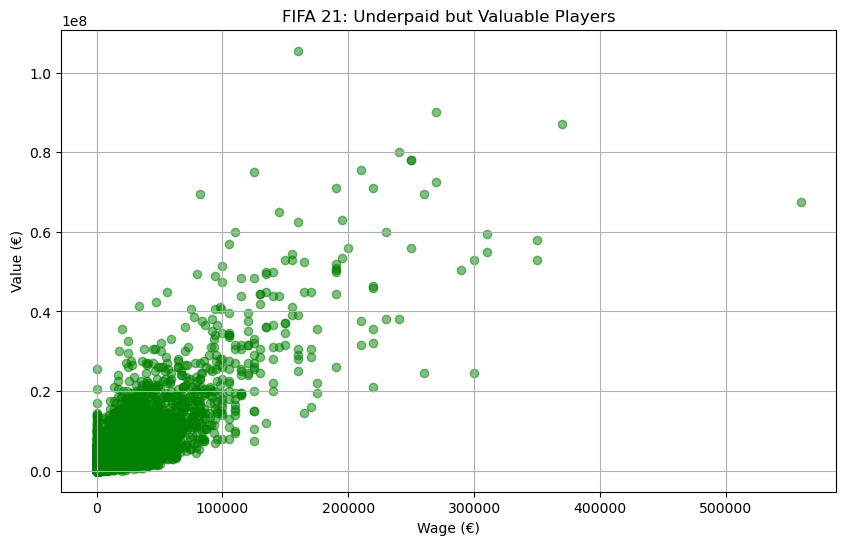

In [31]:
#Scatter Plot: Underpaid Stars
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(df["Wage_num"], df["Value_num"], alpha=0.5, color='green')
plt.xlabel("Wage (€)")
plt.ylabel("Value (€)")
plt.title("FIFA 21: Underpaid but Valuable Players")
plt.grid(True)
# Save plot as image
plt.savefig("FIFA21_value_vs_wage.png", dpi=300, bbox_inches='tight')

plt.show()

In [22]:
df.columns

Index(['photoUrl', 'LongName', 'playerUrl', 'Nationality', 'Positions', 'Name',
       'Age', '↓OVA', 'POT', 'Team & Contract', 'ID', 'Height', 'Weight',
       'foot', 'BOV', 'BP', 'Growth', 'Joined', 'Loan Date End', 'Value',
       'Wage', 'Release Clause', 'Attacking', 'Crossing', 'Finishing',
       'Heading Accuracy', 'Short Passing', 'Volleys', 'Skill', 'Dribbling',
       'Curve', 'FK Accuracy', 'Long Passing', 'Ball Control', 'Movement',
       'Acceleration', 'Sprint Speed', 'Agility', 'Reactions', 'Balance',
       'Power', 'Shot Power', 'Jumping', 'Stamina', 'Strength', 'Long Shots',
       'Mentality', 'Aggression', 'Interceptions', 'Positioning', 'Vision',
       'Penalties', 'Composure', 'Defending', 'Marking', 'Standing Tackle',
       'Sliding Tackle', 'Goalkeeping', 'GK Diving', 'GK Handling',
       'GK Kicking', 'GK Positioning', 'GK Reflexes', 'Total Stats',
       'Base Stats', 'W/F', 'SM', 'A/W', 'D/W', 'IR', 'PAC', 'SHO', 'PAS',
       'DRI', 'DEF', 'PHY', 'Hits

## long-term players

In [23]:
import pandas as pd
import numpy as np

# --- Make sure 'Joined' is datetime ---
df["Joined"] = pd.to_datetime(df["Joined"], errors='coerce')

# --- Create 'Years_at_club' safely ---
df["Years_at_club"] = np.where(df["Joined"].notna(), 2021 - df["Joined"].dt.year, np.nan)

# --- Filter players who have been at a club for more than 10 years ---
long_term_players = df[df["Years_at_club"] > 10]

# --- Select relevant columns & sort descending ---
long_term_players = long_term_players[["Name", "Team & Contract", "Years_at_club"]].sort_values(by="Years_at_club", ascending=False)

# --- Show top 10 longest-serving players ---
long_term_players.head(10)

,Name,Team & Contract,Years_at_club
10282,H. Sogahata,\n\n\n\nKashima Antlers\n1998 ~ 2021\n\n,23.0
9955,D. Lewington,\n\n\n\nMilton Keynes Dons\n2002 ~ 2021\n\n,19.0
4785,Kim Kwang Suk,\n\n\n\nPohang Steelers\n2002 ~ 2020\n\n,19.0
501,I. Akinfeev,\n\n\n\nPFC CSKA Moscow\n2002 ~ 2022\n\n,19.0
11067,M. Bloomfield,\n\n\n\nWycombe Wanderers\n2003 ~ 2022\n\n,18.0
11714,H. Otani,\n\n\n\nKashiwa Reysol\n2003 ~ 2021\n\n,18.0
6431,K. Nakamura,\n\n\n\nKawasaki Frontale\n2003 ~ 2021\n\n,18.0
14453,D. Zibung,\n\n\n\nFC Luzern\n2003 ~ 2021\n\n,18.0
15538,M. McNulty,\n\n\n\nCork City\n2003 ~ 2020\n\n,18.0
4053,P. Karlsson,\n\n\n\nAIK\n2003 ~ 2020\n\n,18.0


In [24]:
# Example (if not already done)
df["Value_num"] = df["Value"].apply(convert_currency)
df["Wage_num"] = df["Wage"].apply(convert_currency)

# 4. Feature Engineering

A new feature `Years_at_club` was created using the 'Joined' column to determine player loyalty and long-term tenure.

In [25]:
def convert_currency(value):
    try:
        value = str(value).strip().replace('€','')
        if 'M' in value:
            return float(value.replace('M','')) * 1_000_000
        elif 'K' in value:
            return float(value.replace('K','')) * 1_000
        else:
            return float(value)
    except:
        return np.nan

df["Wage_num"] = df["Wage"].apply(convert_currency)
df["Value_num"] = df["Value"].apply(convert_currency)

In [26]:
# Step 1: Convert Wage and Value to numeric in the original df
def convert_currency(value):
    try:
        value = str(value).strip().replace('€','')
        if 'M' in value:
            return float(value.replace('M','')) * 1_000_000
        elif 'K' in value:
            return float(value.replace('K','')) * 1_000
        else:
            return float(value)
    except:
        return np.nan

df["Wage_num"] = df["Wage"].apply(convert_currency)
df["Value_num"] = df["Value"].apply(convert_currency)

# Step 2: Filter long-term players AND make a copy
long_term_players = df[df["Years_at_club"] > 10].copy()

In [27]:
long_term_players[["Name", "Team & Contract", "Years_at_club", "Wage_num", "Value_num"]].head(10)

,Name,Team & Contract,Years_at_club,Wage_num,Value_num
0,L. Messi,\n\n\n\nFC Barcelona\n2004 ~ 2021\n\n,17.0,560000.0,67500000.0
15,K. Benzema,\n\n\n\nReal Madrid\n2009 ~ 2022\n\n,12.0,350000.0,53000000.0
16,Sergio Ramos,\n\n\n\nReal Madrid\n2005 ~ 2021\n\n,16.0,300000.0,24500000.0
23,H. Kane,\n\n\n\nTottenham Hotspur\n2010 ~ 2024\n\n,11.0,220000.0,71000000.0
40,Sergio Busquets,\n\n\n\nFC Barcelona\n2008 ~ 2023\n\n,13.0,240000.0,38000000.0
47,G. Chiellini,\n\n\n\nJuventus\n2005 ~ 2021\n\n,16.0,94000.0,15500000.0
54,T. Müller,\n\n\n\nFC Bayern München\n2008 ~ 2023\n\n,13.0,130000.0,42000000.0
60,Piqué,\n\n\n\nFC Barcelona\n2008 ~ 2022\n\n,13.0,220000.0,21000000.0
81,L. Insigne,\n\n\n\nNapoli\n2010 ~ 2022\n\n,11.0,120000.0,37500000.0
126,D. Alaba,\n\n\n\nFC Bayern München\n2010 ~ 2021\n\n,11.0,105000.0,27500000.0


## Scattered plot of underpaid vs high valued players

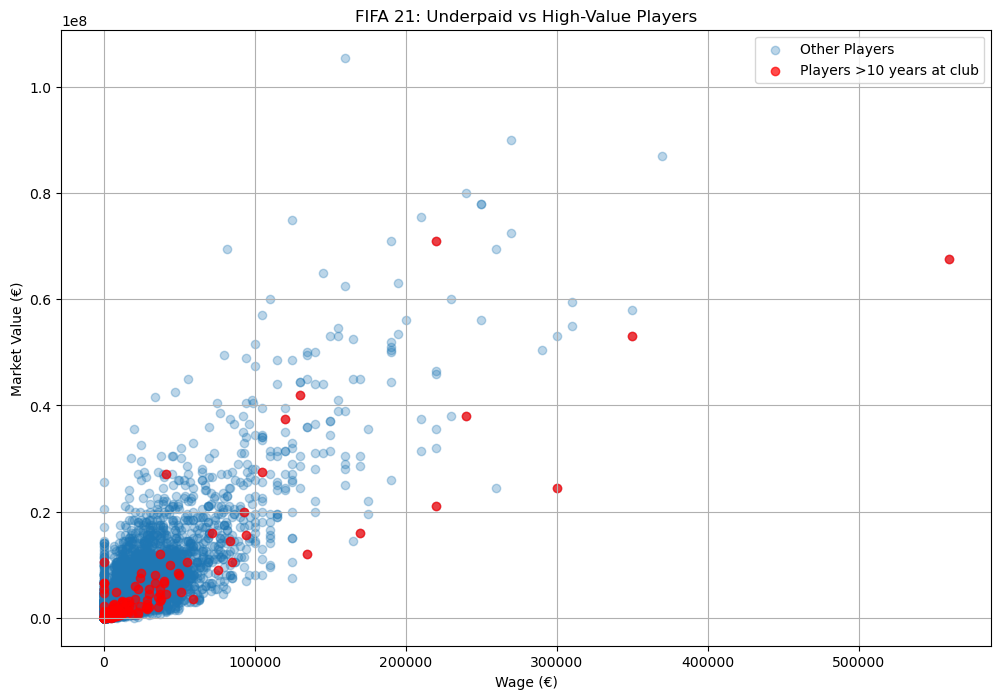

In [32]:
#
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

plt.scatter(df["Wage_num"], df["Value_num"], alpha=0.3, label="Other Players")
plt.scatter(
    long_term_players["Wage_num"], 
    long_term_players["Value_num"], 
    color='red', 
    alpha=0.7, 
    label="Players >10 years at club"
)

plt.xlabel("Wage (€)")
plt.ylabel("Market Value (€)")
plt.title("FIFA 21: Underpaid vs High-Value Players")
plt.legend()
plt.grid(True)
plt.show()

## underpaid but valuable players

In [29]:
# Filter underpaid but valuable players
underpaid_gems = df[(df["Value_num"] > 20_000_000) & (df["Wage_num"] < 10_000)]

# Select the columns we want to show
underpaid_gems = underpaid_gems[["Name", "Team & Contract", "Value_num", "Wage_num", "Years_at_club"]]

# Sort by Value descending
underpaid_gems = underpaid_gems.sort_values(by="Value_num", ascending=False)

# Show top 10 gems
underpaid_gems.head(10)

,Name,Team & Contract,Value_num,Wage_num,Years_at_club
156,Pau López,\n\n\n\nRoma\n2019 ~ 2024\n\n,25500000.0,500.0,2.0
378,V. Tsygankov,\n\n\n\nDynamo Kyiv\n2015 ~ 2023\n\n,20500000.0,500.0,6.0


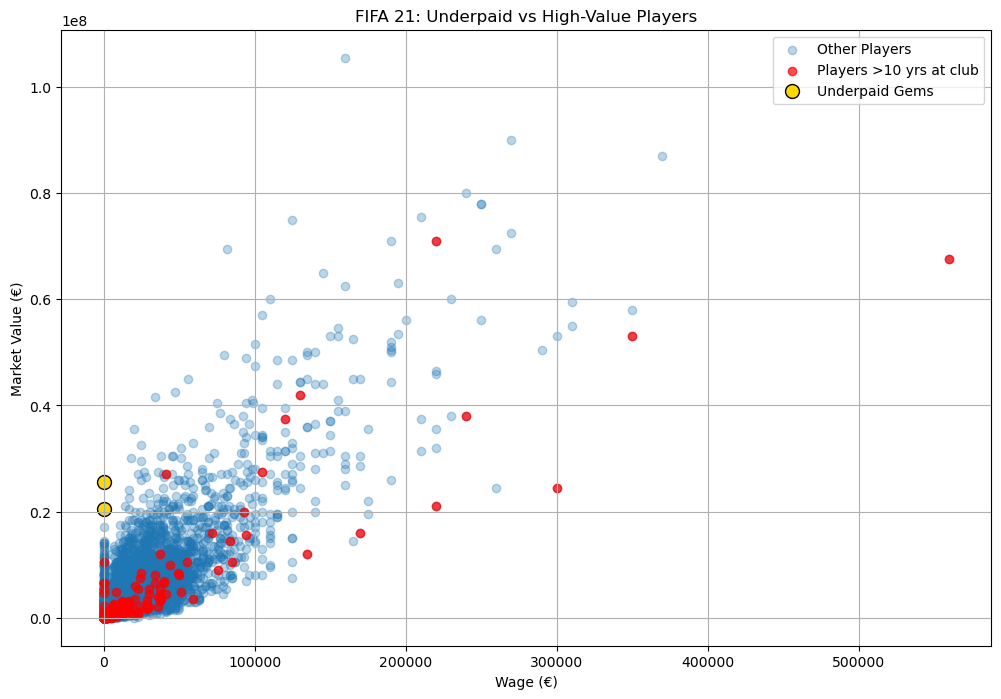

In [30]:
##Red dots → loyal veterans

#Gold dots → underpaid gems

#Scatter clearly shows high-value but low-wage players, perfect for storytelling.
plt.figure(figsize=(12,8))

# All players
plt.scatter(df["Wage_num"], df["Value_num"], alpha=0.3, label="Other Players")

# Long-term loyal players (>10 yrs)
plt.scatter(
    long_term_players["Wage_num"], 
    long_term_players["Value_num"], 
    color='red', 
    alpha=0.7, 
    label="Players >10 yrs at club"
)

# Underpaid gems
plt.scatter(
    underpaid_gems["Wage_num"], 
    underpaid_gems["Value_num"], 
    color='gold', 
    edgecolors='black', 
    s=100, 
    label="Underpaid Gems"
)

plt.xlabel("Wage (€)")
plt.ylabel("Market Value (€)")
plt.title("FIFA 21: Underpaid vs High-Value Players")
plt.legend()
plt.grid(True)
plt.show()

# 5. Key Insights

1. Player market values ranged up to €105.5M after cleaning and conversion.
2. Several players have remained at their clubs for over 10 years, indicating strong loyalty.
3. A subset of players demonstrate high market value while earning relatively low wages, suggesting potential undervaluation.
4. The dataset required significant preprocessing due to inconsistent string formatting from web scraping.

# 6. Conclusion

This project demonstrates practical data cleaning, feature engineering, and exploratory data analysis skills using real-world messy data.

The workflow ensures reproducibility and structured transformation from raw scraped data to analysis-ready insights.

In [33]:
plt.savefig("FIFA21_value_vs_wage.png")

<Figure size 640x480 with 0 Axes>

In [38]:
import os

# Create a folder called 'plots' if it doesn't exist
os.makedirs("plots", exist_ok=True)

# Check where it's created
print("Current working directory:", os.getcwd())
print("Plots folder ready at:", os.path.join(os.getcwd(), "plots"))

Current working directory: C:\Users\Grace Sikeina Mahama\Downloads
Plots folder ready at: C:\Users\Grace Sikeina Mahama\Downloads\plots


In [39]:
plt.savefig("plots/FIFA21_value_vs_wage.png", dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [40]:
print(os.listdir("plots"))

['FIFA21_value_vs_wage.png']


Plots folder ready at: C:\Users\Grace Sikeina Mahama\Downloads\plots


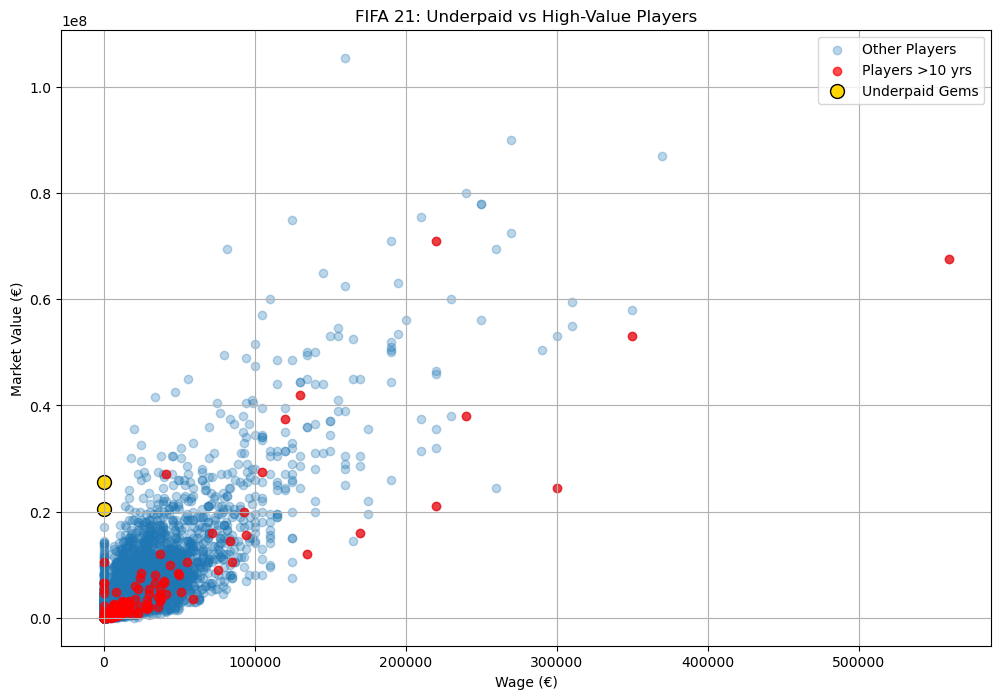

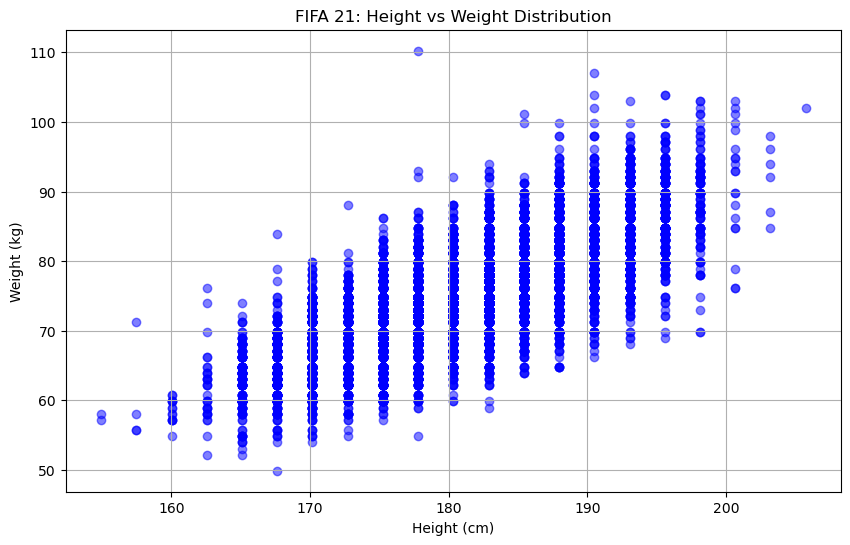

In [41]:
import os
import matplotlib.pyplot as plt

# ------------------------------
# Step 1: Create plots folder
# ------------------------------
os.makedirs("plots", exist_ok=True)
print(f"Plots folder ready at: {os.path.join(os.getcwd(), 'plots')}")

# ------------------------------
# Step 2: Value vs Wage Scatter Plot
# ------------------------------
plt.figure(figsize=(12,8))
plt.scatter(df["Wage_num"], df["Value_num"], alpha=0.3, label="Other Players")
plt.scatter(
    long_term_players["Wage_num"], 
    long_term_players["Value_num"], 
    color='red', alpha=0.7, label="Players >10 yrs"
)
plt.scatter(
    underpaid_gems["Wage_num"], 
    underpaid_gems["Value_num"], 
    color='gold', edgecolors='black', s=100, label="Underpaid Gems"
)
plt.xlabel("Wage (€)")
plt.ylabel("Market Value (€)")
plt.title("FIFA 21: Underpaid vs High-Value Players")
plt.legend()
plt.grid(True)

# Save plot
plt.savefig("plots/FIFA21_value_vs_wage.png", dpi=300, bbox_inches='tight')
plt.show()

# ------------------------------
# Step 3: Height vs Weight Scatter Plot (optional)
# ------------------------------
plt.figure(figsize=(10,6))
plt.scatter(df["Height_cm"], df["Weight_kg"], alpha=0.5, c='blue')
plt.xlabel("Height (cm)")
plt.ylabel("Weight (kg)")
plt.title("FIFA 21: Height vs Weight Distribution")
plt.grid(True)

# Save plot
plt.savefig("plots/FIFA21_height_vs_weight.png", dpi=300, bbox_inches='tight')
plt.show()

In [42]:
import os
print(os.getcwd())  # Shows where your notebook is running from

C:\Users\Grace Sikeina Mahama\Downloads
